# ETC and TC Frequency: New (Re-run) vs Previous Production

## Purpose
The ETC and TC tracking masks were updated upstream (Bryce Harrop, 2026-09-25): quasi-stationary storms (movement below 3.0 great-circle degrees for 48 h) were removed
from the TempestExtremes stitched-node tracks, and the masks were rebuilt. This notebook shows how much the **annual ETC frequency** and the **annual TC frequency** changed in the
re-run of the COF pipeline, for all six sources.

For each of ETC and TC there is one figure, one row per source:
- **left column**: the annual frequency of the **new** data (%)
- **right column**: **new - old** (percentage points), where old is the previous production data

## Inputs
Monthly COF files `{source}_monthly_rainmap_cof_hp8_v1.nc` (Step 4 of Analysis 1): `etc_count` and `tc_count` are counts of time steps with the feature present in a cell,
`ntimes` is the number of time steps of the month. Frequency = 100 * sum(count) / sum(ntimes), as in `plot_cof_annual_map.ipynb`.
- new: the re-run tree (`dir_new`)
- old: the production files (`dir_old`)

## Notes
- All six sources are shown: OBS (ERA5/IMERG) and the five GSRMs (SCREAM, ICON, NICAM, UM, CASESM2), all genuinely re-processed - none of the "new" files are links to the old ones (checked below).
- OBS/ERA5's masks were reprocessed 2026-09-28, once Bryce delivered complete AR/TC/ETC masks for 2019-2021; TC is essentially unchanged (the quasi-stationary filter removes no 2019-2021 ERA5 TC storm), ETC decreases by a few points in the same regions as the GSRMs.
- The difference is a change in the **feature footprint** (the track-center mask of 5 degrees for TC and 10 degrees for ETC), so removing one long-lived stationary storm removes a whole disc.

In [1]:
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import copy, os
import colormaps as cmaps
import easygems.healpix as egh

## Paths and settings

In [2]:
# New data: the re-run (tmp tree). After the re-run has been promoted to production, point dir_new to production and dir_old to the archived previous version.
# dir_new = '/global/cfs/cdirs/wcm_shr/hk25/cof_masks/stats/monthly/'
dir_new = '/pscratch/sd/w/wcmca1/hackathon/tmp/tcfix_20260925/cof_masks/stats/monthly/'
# Old data: previous production
dir_old = '/global/cfs/cdirs/wcm_shr/hk25/cof_masks/stats/monthly/'

name_map = {
    'obs': 'IMERGv7',
    'm1': 'scream',
    'm2': 'icon_d3hp003',
    'm3': 'nicam_gl11',
    'm4': 'um_glm_n2560_RAL3p3',
    'm5': 'casesm2_10km_nocumulus',
}
name_map_plot = {
    'obs': 'OBS',
    'm1': 'SCREAM',
    'm2': 'ICON',
    'm3': 'NICAM',
    'm4': 'UM',
    'm5': 'CASESM2',
}

# Sources to plot, one row each. Only the sources that were re-processed (the others have no difference).
plot_sources = ['obs', 'm1', 'm2', 'm3', 'm4', 'm5']

files_new = {key: f'{dir_new}{name_map[key]}_monthly_rainmap_cof_hp8_v1.nc' for key in plot_sources}
files_old = {key: f'{dir_old}{name_map[key]}_monthly_rainmap_cof_hp8_v1.nc' for key in plot_sources}

figdir = '/pscratch/sd/w/wcmca1/hackathon/tmp/tcfix_20260925/figures/figures_cof_202609/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

/pscratch/sd/w/wcmca1/hackathon/tmp/tcfix_20260925/figures/figures_cof_202609/


### Check that the input files exist, and that new is not just a link to old

In [3]:
for key in plot_sources:
    fn, fo = files_new[key], files_old[key]
    print(f'{name_map_plot[key]:8s} new: {os.path.isfile(fn)}   old: {os.path.isfile(fo)}')
    assert os.path.isfile(fn) and os.path.isfile(fo), f'missing input for {key}'
    if os.path.realpath(fn) == os.path.realpath(fo):
        print(f'   WARNING: the new file of {name_map_plot[key]} is the old file (not re-processed), the difference will be zero')

OBS      new: True   old: True
SCREAM   new: True   old: True
ICON     new: True   old: True
NICAM    new: True   old: True
UM       new: True   old: True
CASESM2  new: True   old: True


## Annual frequency of ETC and TC, new and old

In [4]:
features = ['etc', 'tc']

def annual_frequency(path):
    """Annual frequency (%) of each feature: 100 * sum over time of <feature>_count / sum over time of ntimes."""
    ds = xr.open_dataset(path)
    ntimes = ds.ntimes.sum(dim='time')
    freq = {f: (100. * ds[f'{f}_count'].sum(dim='time') / ntimes).compute() for f in features}
    return freq, ds.lat.load().values, ((ds.lon.load().values + 180) % 360) - 180

freq_new, freq_old = {}, {}
for key in plot_sources:
    freq_new[key], hp_lat, hp_lon = annual_frequency(files_new[key])
    freq_old[key], lat_old, lon_old = annual_frequency(files_old[key])
    assert np.allclose(hp_lat, lat_old) and np.allclose(hp_lon, lon_old), 'the grids differ'
    print(key, 'done')

obs done
m1 done
m2 done
m3 done
m4 done
m5 done


### Summary of the change (60S-60N)

In [5]:
band = np.abs(hp_lat) <= 60
print(f"{'source':8s} {'feature':7s} {'mean new':>9s} {'mean old':>9s} {'change':>8s} {'largest decrease':>26s} {'largest increase':>26s}")
for key in plot_sources:
    for f in features:
        new, old = freq_new[key][f].values, freq_old[key][f].values
        d = np.where(band, new - old, np.nan)
        imin, imax = np.nanargmin(d), np.nanargmax(d)
        print(f"{name_map_plot[key]:8s} {f.upper():7s} {new[band].mean():9.3f} {old[band].mean():9.3f} {new[band].mean() - old[band].mean():+8.3f} "
              f"{d[imin]:+8.2f} at {hp_lat[imin]:6.1f}N {hp_lon[imin]:7.1f}E {d[imax]:+8.2f} at {hp_lat[imax]:6.1f}N {hp_lon[imax]:7.1f}E")

source   feature  mean new  mean old   change           largest decrease           largest increase
OBS      ETC         8.987     9.243   -0.257    -5.11 at   26.3N    96.2E    +0.05 at  -51.1N   137.2E
OBS      TC          0.308     0.308   -0.000    -0.07 at  -12.3N   166.1E    +0.09 at  -16.8N   178.9E
SCREAM   ETC         8.031     8.367   -0.337    -9.83 at   35.0N    96.9E    +0.00 at    0.1N    45.0E
SCREAM   TC          0.385     0.388   -0.003    -1.27 at    7.0N  -112.5E    +0.00 at    0.1N    45.0E
ICON     ETC         7.294     7.774   -0.481   -22.60 at   34.8N  -117.4E    +0.00 at    0.1N    45.0E
ICON     TC          0.318     0.321   -0.004    -1.78 at  -13.4N   114.3E    +0.00 at    0.1N    45.0E
NICAM    ETC         8.739     8.933   -0.194    -4.66 at   32.3N    69.3E    +0.00 at    0.1N    45.0E
NICAM    TC          0.560     0.560   +0.000    +0.00 at    0.1N    45.0E    +0.00 at    0.1N    45.0E
UM       ETC         8.355     8.593   -0.238    -3.68 at  -59.9N   

## Function to plot new data (left) and new - old (right)

In [6]:
def plot_maps_new_and_diff_grid(
    new_list,
    old_list,
    titles,
    new_levels,
    diff_levels,
    new_colormap,
    diff_colormap,
    new_cblabel,
    diff_cblabel,
    new_cbticks=None,
    diff_cbticks=None,
    figname=None,
    figtitle=None,
    new_oob_colors=None,
    diff_oob_colors=None,
    wspace=0.02,
    hspace=0.08,
    cbar_wspace=0.13,
    cbar_width=0.02,
    figsize=None,
    fontsize=14,
    cb_fontsize=12,
    title_y=0.995,
    top=0.90,
    bottom=0.05,
    lat_range=None,
    lat_label=None,
    lon_label=None,
    show_gridlines=False,
    lat_lines=None,
    left_margin=0.01,
    right_margin=0.01,
    contourf=False,
    dpi=200,
):
    """
    Plot one row per source: the new data in the left column and new - old in the right column.

    Layout:  [new colorbar | 2-column map grid | difference colorbar]

    Parameters
    ----------
    new_list, old_list : lists of DataArray (HEALPix, one per row) with the new and the old data.
    titles : 2-D list [[left title, right title], ...], one inner list per row.
    new_levels, diff_levels : boundaries of the color intervals (BoundaryNorm) of the new data and the difference.
    new_colormap, diff_colormap : colormap names or objects.
    new_cbticks, diff_cbticks : colorbar ticks (default: the levels).
    new_oob_colors, diff_oob_colors : optional {'over': color, 'under': color}.
    wspace, hspace : spacing between the maps.
    top, bottom : top and bottom of the map grid as a fraction of the figure height (the figure title sits above 'top', at title_y).
    cbar_wspace, cbar_width : spacing between the colorbars and the map grid, and their width.
    lat_label, lon_label : 2-D lists of bool (rows x 2), which panels get latitude / longitude labels.
    lat_lines : latitudes of dashed lines (e.g. the tropics).
    """
    nrow = len(new_list)
    if len(old_list) != nrow or len(titles) != nrow:
        raise ValueError('new_list, old_list and titles must have one item per row.')
    if new_cbticks is None:
        new_cbticks = new_levels
    if diff_cbticks is None:
        diff_cbticks = diff_levels
    if lat_label is None:
        lat_label = [[False, False] for _ in range(nrow)]
    if lon_label is None:
        lon_label = [[False, False] for _ in range(nrow)]
    if figsize is None:
        figsize = (15, 2.85 * nrow + 0.8)

    mpl.rcParams['font.size'] = fontsize

    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    land = cf.NaturalEarthFeature('physical', 'land', '110m')

    fig = plt.figure(figsize=figsize, dpi=100)
    fig.subplots_adjust(left=left_margin, right=1 - right_margin, top=top, bottom=bottom)

    # [new colorbar | maps | difference colorbar]; cbar_wspace does not affect the map spacing.
    gs_cb = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[cbar_width, 1, cbar_width], wspace=cbar_wspace)
    gs_maps = gridspec.GridSpecFromSubplotSpec(nrow, 2, subplot_spec=gs_cb[1], wspace=wspace, hspace=hspace)

    new_cmap = copy.copy(mpl.colormaps.get_cmap(new_colormap))
    diff_cmap = copy.copy(mpl.colormaps.get_cmap(diff_colormap))
    if new_oob_colors is not None:
        new_cmap.set_over(new_oob_colors['over'])
        new_cmap.set_under(new_oob_colors['under'])
    if diff_oob_colors is not None:
        diff_cmap.set_over(diff_oob_colors['over'])
        diff_cmap.set_under(diff_oob_colors['under'])
    new_norm = colors.BoundaryNorm(boundaries=new_levels, ncolors=new_cmap.N)
    diff_norm = colors.BoundaryNorm(boundaries=diff_levels, ncolors=diff_cmap.N)

    new_plot, diff_plot = None, None
    for row in range(nrow):
        new_data = new_list[row]
        panels = [new_data, new_data - old_list[row]]
        for col in range(2):
            ax = fig.add_subplot(gs_maps[row, col], projection=proj)
            ax.set_global()
            ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
            ax.set_aspect('auto', adjustable=None)
            ax.set_title(titles[row][col], fontsize=fontsize, loc='left')

            norm, cmap = (new_norm, new_cmap) if col == 0 else (diff_norm, diff_cmap)
            if contourf:
                im = egh.healpix_contour(panels[col], ax=ax, norm=norm, cmap=cmap, transform=data_proj, zorder=2)
            else:
                im = egh.healpix_show(panels[col], ax=ax, norm=norm, cmap=cmap, zorder=2)
            if col == 0:
                new_plot = im
            else:
                diff_plot = im

            if lat_lines is not None:
                line_lons = np.linspace(-180, 180, 361)
                for latitude in lat_lines:
                    ax.plot(line_lons, np.full_like(line_lons, latitude), color='k', linestyle='--', linewidth=1.5,
                            transform=data_proj, zorder=4, alpha=0.8)

            if lat_range is not None:
                _, y_min = proj.transform_point(0, lat_range[0], data_proj)
                _, y_max = proj.transform_point(0, lat_range[1], data_proj)
                ax.set_ylim(y_min, y_max)

            if show_gridlines:
                draw_labels = lat_label[row][col] or lon_label[row][col]
                gl = ax.gridlines(crs=data_proj, draw_labels=draw_labels, linestyle='--', linewidth=0.5,
                                  color='gray', alpha=0.8, zorder=10)
                if draw_labels:
                    gl.top_labels = False
                    gl.right_labels = False
                    gl.left_labels = lat_label[row][col]
                    gl.bottom_labels = lon_label[row][col]
                    gl.xlabel_style = {'size': fontsize - 2}
                    gl.ylabel_style = {'size': fontsize - 2}

    # Left colorbar: new data
    cax_new = fig.add_subplot(gs_cb[0])
    cbar_new = fig.colorbar(new_plot, cax=cax_new, ticks=new_cbticks, orientation='vertical', extend='both')
    cbar_new.ax.yaxis.set_ticks_position('left')
    cbar_new.ax.yaxis.set_label_position('left')
    cbar_new.ax.tick_params(labelsize=cb_fontsize)
    cbar_new.set_label(new_cblabel, fontsize=cb_fontsize)

    # Right colorbar: new - old
    cax_diff = fig.add_subplot(gs_cb[2])
    cbar_diff = fig.colorbar(diff_plot, cax=cax_diff, ticks=diff_cbticks, orientation='vertical', extend='both')
    cbar_diff.ax.tick_params(labelsize=cb_fontsize)
    cbar_diff.set_label(diff_cblabel, fontsize=cb_fontsize)

    if figtitle:
        fig.suptitle(figtitle, fontsize=fontsize + 2, fontweight='bold', y=title_y)

    if figname:
        fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
        print(f'Figure saved: {figname}')

    return fig

## Common plot settings

In [7]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    # Truncate a colormap (used so that the lowest color of a shading is not white).
    return mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval), cmap(np.linspace(minval, maxval, n)))

tropics_lat = [-20, 20]
nrow = len(plot_sources)
letters = 'abcdefghijklmnopqrstuvwxyz'

# Titles: (a) SCREAM new | (b) SCREAM new - old, ...
titles = [[f"({letters[2*i]}) {name_map_plot[key]} new", f"({letters[2*i + 1]}) {name_map_plot[key]} new - old"]
          for i, key in enumerate(plot_sources)]

# Latitude labels on the left column, longitude labels on the bottom row
lat_label = [[True, False] for _ in range(nrow)]
lon_label = [[False, False] for _ in range(nrow - 1)] + [[True, True]]

## ETC frequency: new and new - old

Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/tcfix_20260925/figures/figures_cof_202609/globalmap_etc_freq_annual_new_vs_old.png


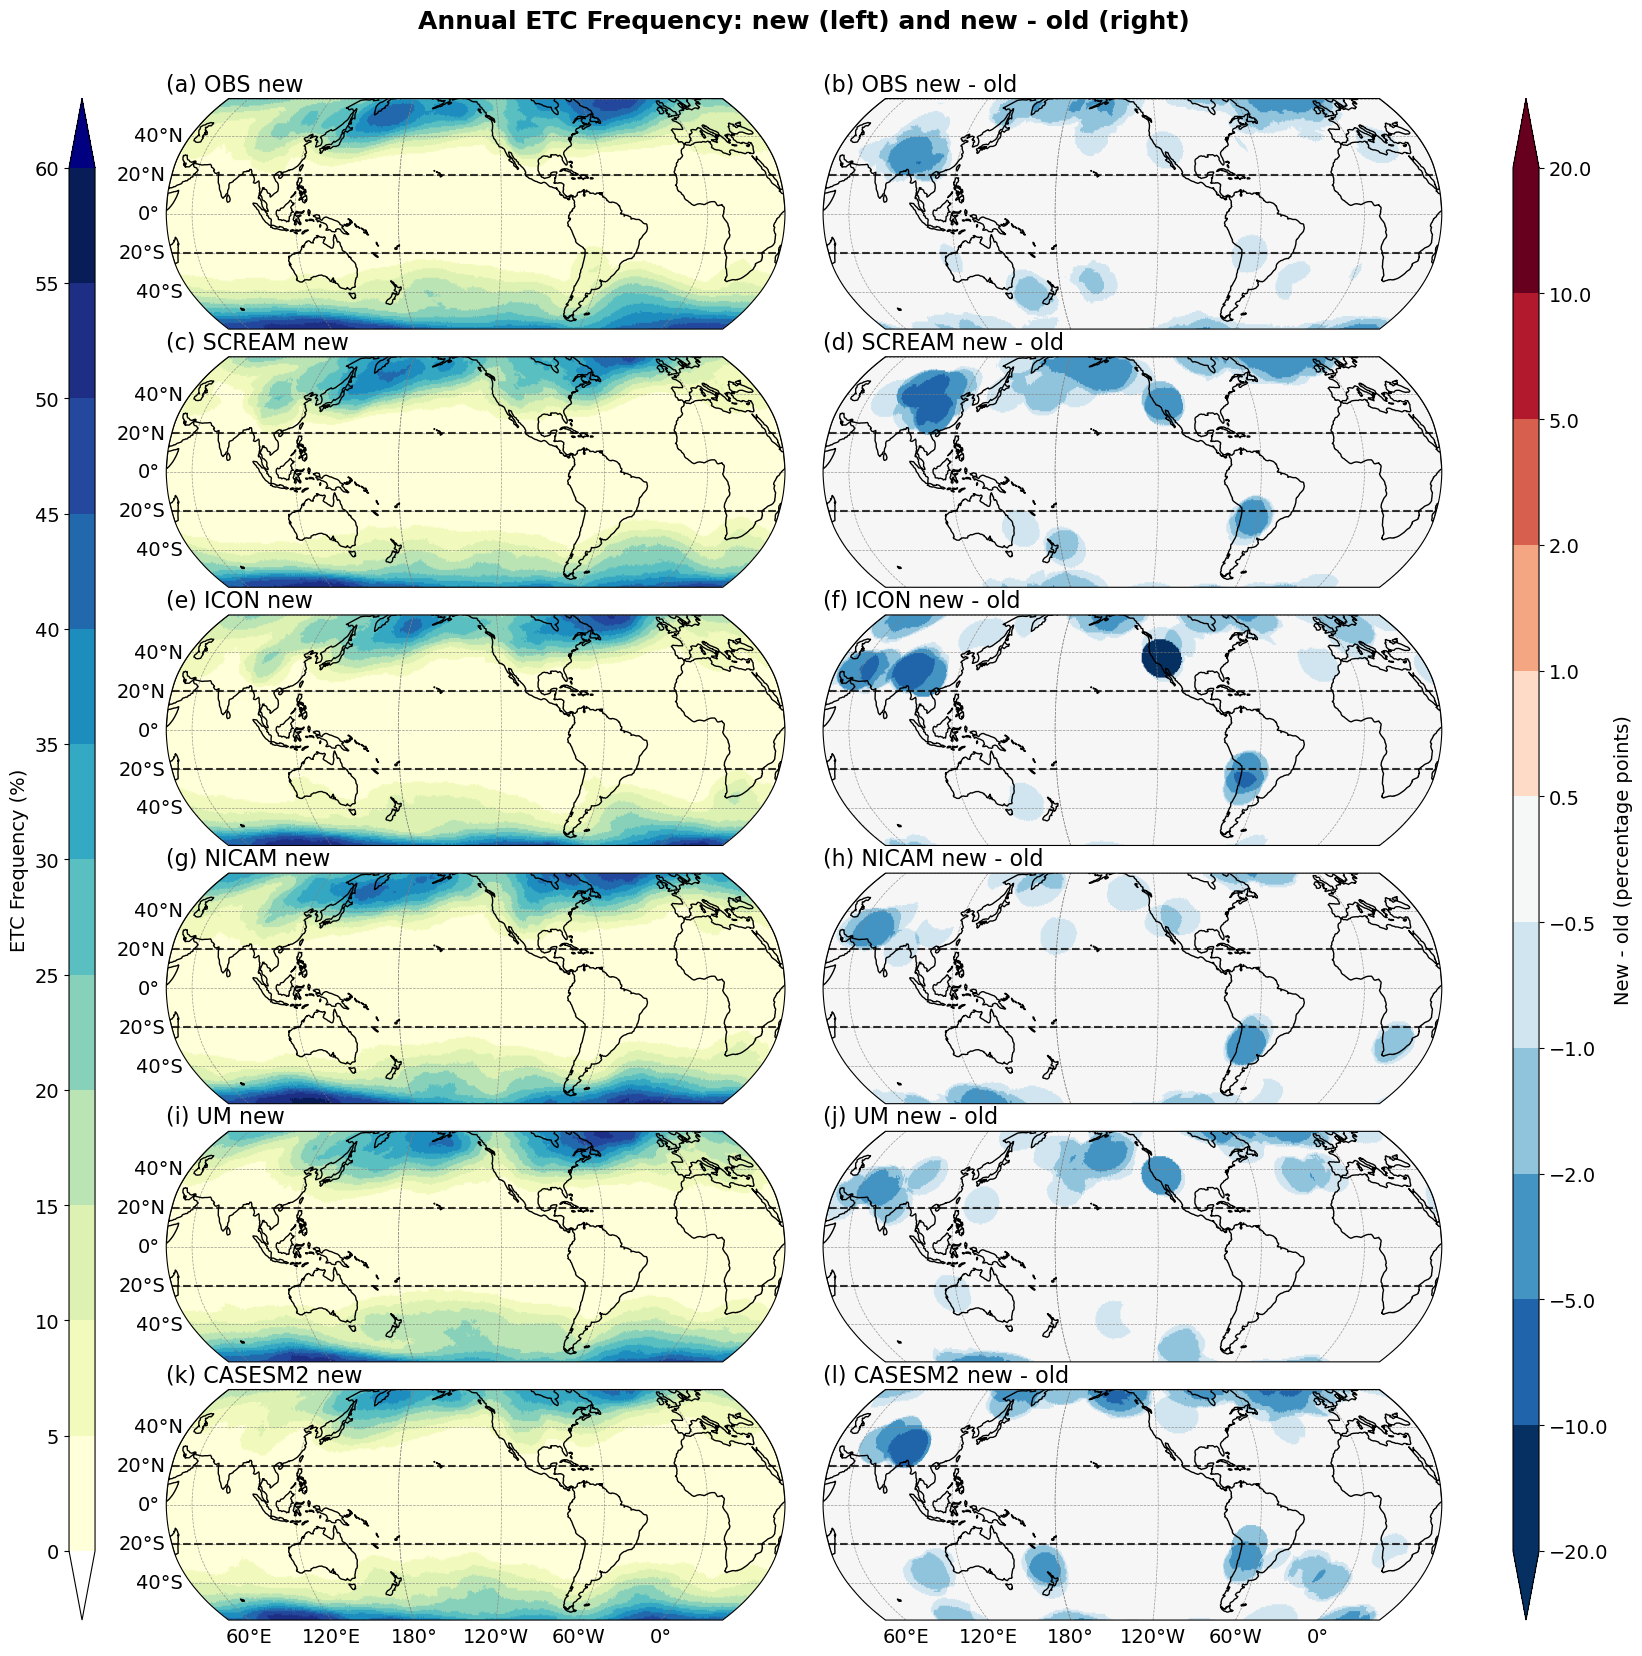

In [11]:
new_levels = np.arange(0, 61, 5)
diff_levels = [-20, -10, -5, -2, -1, -0.5, 0.5, 1, 2, 5, 10, 20]

fig = plot_maps_new_and_diff_grid(
    new_list=[freq_new[key]['etc'] for key in plot_sources],
    old_list=[freq_old[key]['etc'] for key in plot_sources],
    titles=titles,
    new_levels=new_levels,
    diff_levels=diff_levels,
    new_colormap='YlGnBu',
    diff_colormap='RdBu_r',
    new_cblabel='ETC Frequency (%)',
    diff_cblabel='New - old (percentage points)',
    new_cbticks=new_levels,
    diff_cbticks=diff_levels,
    new_oob_colors={'over': 'navy', 'under': 'white'},
    diff_oob_colors=None,
    figname=f'{figdir}globalmap_etc_freq_annual_new_vs_old.png',
    figtitle='Annual ETC Frequency: new (left) and new - old (right)',
    figsize=(15, 2.85 * nrow + 0.8),
    fontsize=16,
    cb_fontsize=14,
    wspace=0.02,
    hspace=0.12,
    title_y=0.95,
    cbar_wspace=0.13,
    cbar_width=0.02,
    lat_range=(-60, 60),
    lat_label=lat_label,
    lon_label=lon_label,
    show_gridlines=True,
    lat_lines=tropics_lat,
    dpi=200,
)
plt.show()

## TC frequency: new and new - old

Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/tcfix_20260925/figures/figures_cof_202609/globalmap_tc_freq_annual_new_vs_old.png


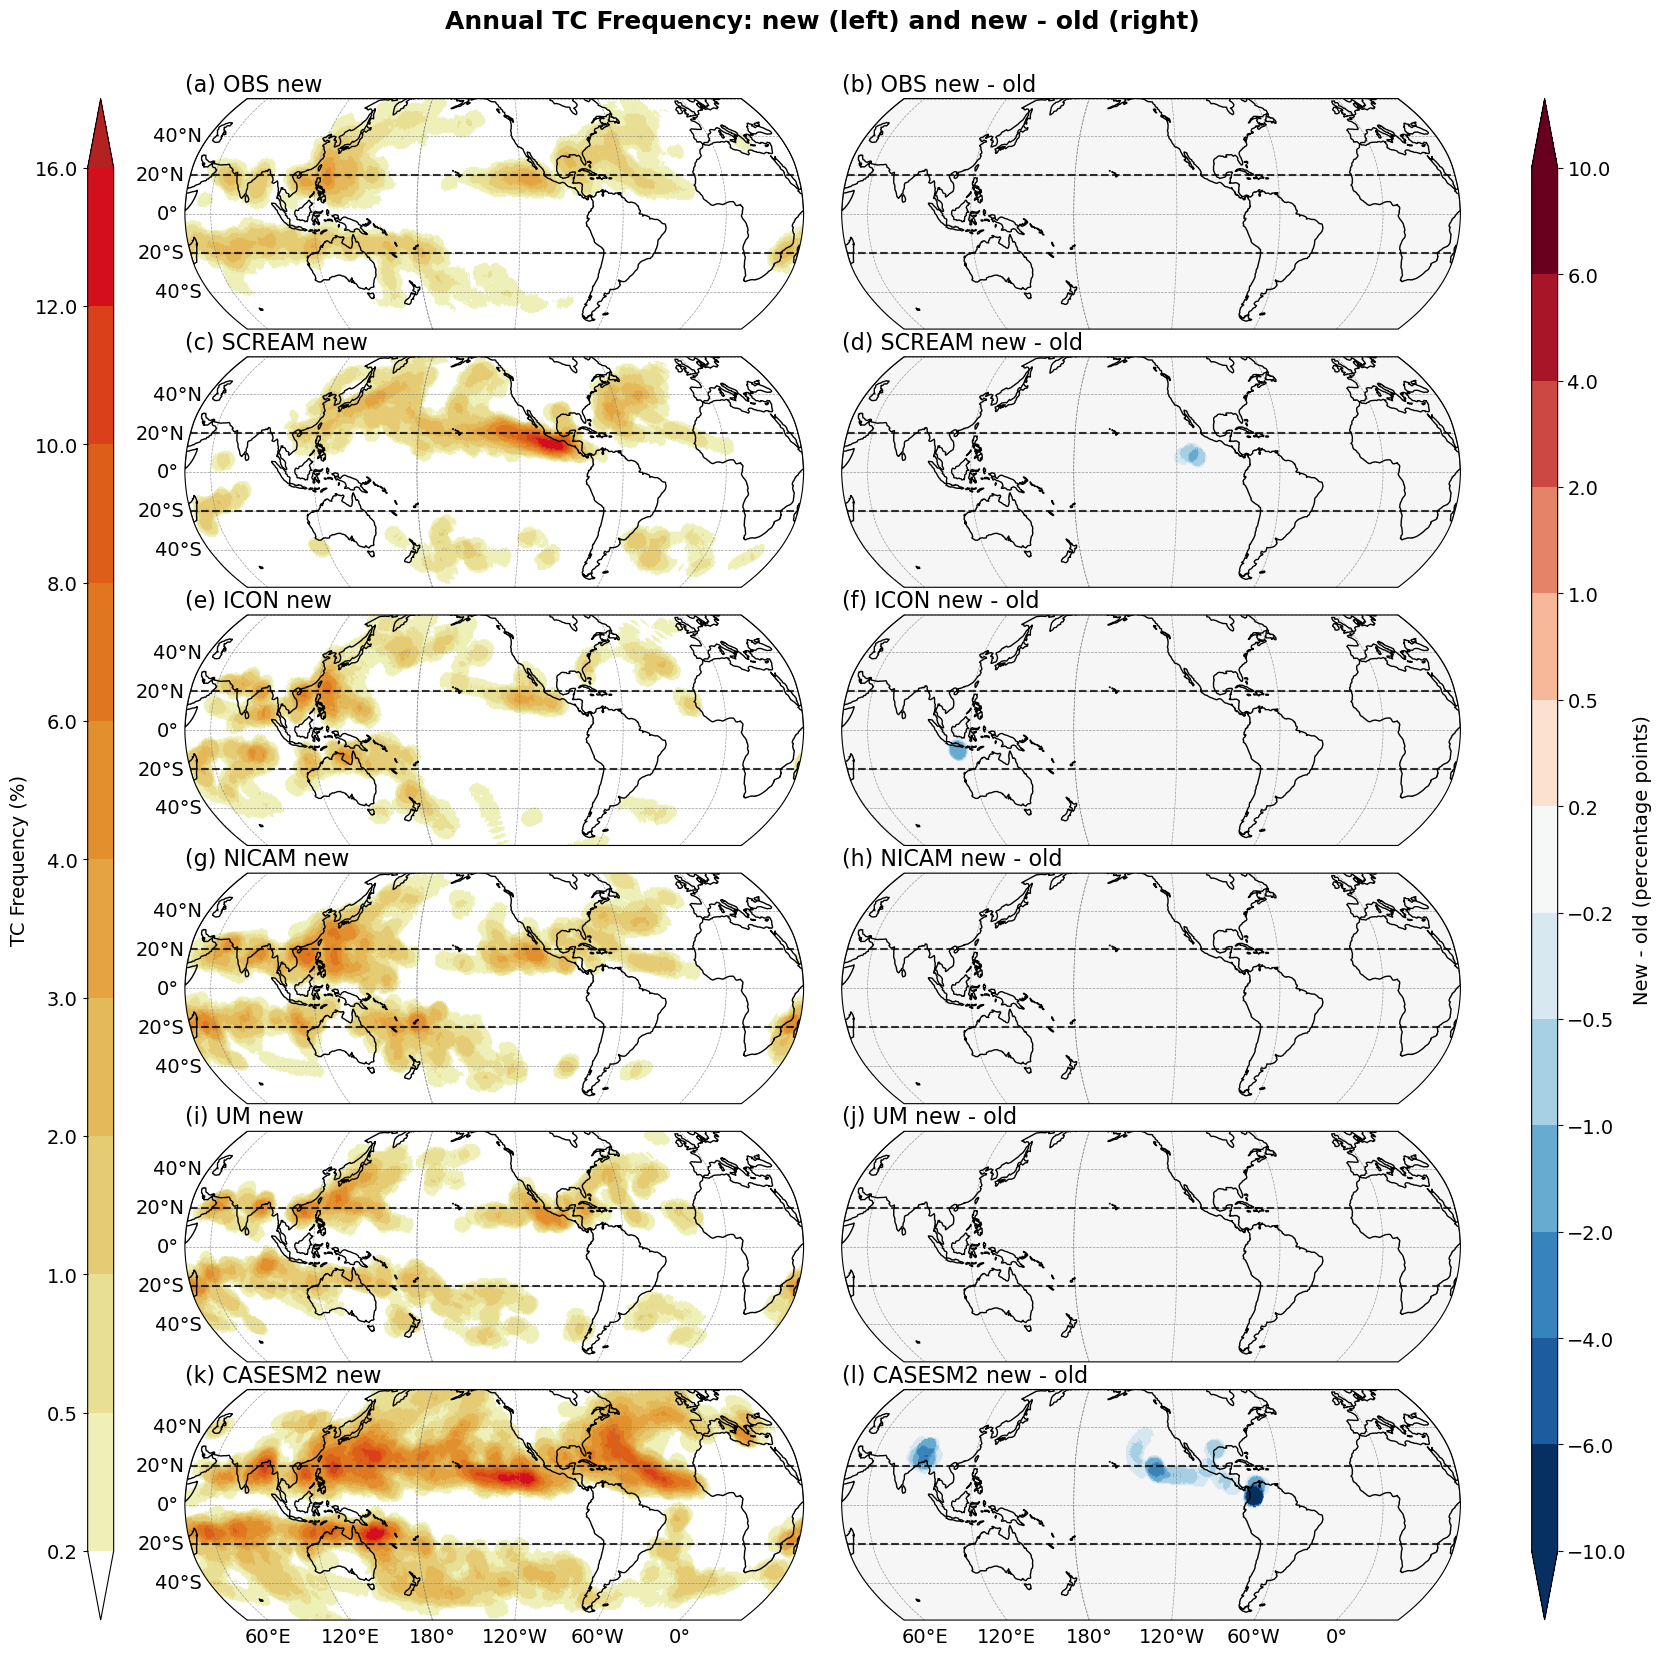

In [12]:
new_levels = [0.2, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16]
diff_levels = [-10, -6, -4, -2, -1, -0.5, -0.2, 0.2, 0.5, 1, 2, 4, 6, 10]

fig = plot_maps_new_and_diff_grid(
    new_list=[freq_new[key]['tc'] for key in plot_sources],
    old_list=[freq_old[key]['tc'] for key in plot_sources],
    titles=titles,
    new_levels=new_levels,
    diff_levels=diff_levels,
    new_colormap=truncate_colormap(cmaps.cet_l_wyor, 0.12, 1.0),
    diff_colormap='RdBu_r',
    new_cblabel='TC Frequency (%)',
    diff_cblabel='New - old (percentage points)',
    new_cbticks=new_levels,
    diff_cbticks=diff_levels,
    new_oob_colors={'over': 'firebrick', 'under': 'white'},
    diff_oob_colors=None,
    figname=f'{figdir}globalmap_tc_freq_annual_new_vs_old.png',
    figtitle='Annual TC Frequency: new (left) and new - old (right)',
    figsize=(15, 2.85 * nrow + 0.8),
    fontsize=16,
    cb_fontsize=14,
    wspace=0.02,
    hspace=0.12,
    title_y=0.95,
    cbar_wspace=0.13,
    cbar_width=0.02,
    lat_range=(-60, 60),
    lat_label=lat_label,
    lon_label=lon_label,
    show_gridlines=True,
    lat_lines=tropics_lat,
    dpi=200,
)
plt.show()